# 06 — Đo độ trễ: đồng bộ GPU, luật Amdahl, chi phí khởi chạy kernel, TensorRT, pipeline

Kết luận về tốc độ của dự án: trên T4 của Kaggle, **giải nén ảnh PNG chậm hơn chạy mạng**; fp16
trong PyTorch không nhanh hơn; TensorRT nhanh gấp 2,6 lần; giải nén song song đưa hệ thống lên 71
khung/giây. Notebook này giải thích từng điều bằng khái niệm và kiểm chứng những gì kiểm được trên
CPU của máy bạn. Số liệu GPU lấy từ `results/latency/`, đo trong **một phiên Kaggle duy nhất**.

| Mục | Câu hỏi |
|---|---|
| 1. Độ trễ và thông lượng | Hai con số khác nhau thế nào? |
| 2. Đo thời gian trên GPU | Vì sao phải đồng bộ trước khi bấm giờ? |
| 3. Thời gian đi đâu | Bảng phân rã theo chặng |
| 4. Luật Amdahl | Tăng tốc một chặng thì cả hệ nhanh lên bao nhiêu? |
| 5. Giới hạn khởi chạy kernel | Vì sao fp16 không giúp gì, còn TensorRT giúp nhiều? |
| 6. Giải nén PNG | Chặng chậm nhất, đo ngay trên máy bạn |
| 7. Pipeline | Chồng chặng CPU lên chặng GPU |

In [1]:
import json, time, inspect
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import cv2
import matplotlib.pyplot as plt

from monodist import kitti

ROOT = Path("../data/kitti_tracking")
LAT = {p.stem: json.loads(p.read_text()) for p in sorted(Path("../results/latency").glob("*.json"))}
plt.rcParams.update({"figure.figsize": (9, 3.2), "figure.dpi": 110})
print(len(LAT), "timed configurations:", ", ".join(LAT))

14 timed configurations: coco_1280, coco_1280_nms, ft_1280, ft_1280_fp16, ft_1280_nms, ft_1280_nms_pipelined, ft_1280_nms_trt16, ft_1280_nms_trt16_pipelined, ft_1280_pipelined, ft_1280_trt16, ft_1280_trt16_pipelined, ft_640, ft_640_trt16, ft_640_trt16_pipelined


## 1. Độ trễ và thông lượng

- **Độ trễ** (latency): thời gian từ lúc một khung hình có mặt đến lúc có kết quả của khung đó.
  Đơn vị ms. Quan trọng khi phải phản ứng (xe phanh).
- **Thông lượng** (throughput): số khung xử lý được mỗi giây (FPS). Quan trọng khi phải theo kịp
  camera (KITTI quay 10 khung/giây).

Nếu các chặng chạy **nối tiếp** thì thông lượng $= 1/\text{độ trễ}$. Nếu các chặng chạy **gối
nhau** (khung sau đang giải nén trong khi khung trước đang chạy mạng), thông lượng bị giới hạn
bởi **chặng chậm nhất** chứ không phải tổng các chặng, còn độ trễ của từng khung gần như giữ
nguyên. Mục 7 đo điều này.

**Ký hiệu mới**
- **FPS** (frames per second): số khung hình mỗi giây

## 2. Đo thời gian trên GPU

Lệnh PyTorch gửi công việc cho GPU **không đợi GPU làm xong**: CPU đặt lệnh vào hàng đợi rồi đi
tiếp ngay (thực thi bất đồng bộ). Nếu bấm giờ bằng đồng hồ CPU mà không đợi, ta chỉ đo thời gian
*gửi lệnh*. Phải gọi `torch.cuda.synchronize()` (chờ mọi lệnh trong hàng đợi xong) trước khi đọc
đồng hồ. Bộ bấm giờ của Ultralytics, thứ dự án dùng cho ba chặng preprocess, inference,
postprocess, làm đúng việc đó:

In [2]:
from ultralytics.utils.ops import Profile
print(inspect.getsource(Profile.time))

    def time(self):
        """Get current time with accelerator synchronization if applicable."""
        if self.accelerator is not None:
            self.accelerator.synchronize(self.device)
        return time.perf_counter()



Các chặng còn lại (đọc file, giải nén, bước đo khoảng cách) chạy trên CPU, bấm bằng
`time.perf_counter()`. Mỗi cấu hình: 300 khung của chuỗi test 0007, 3 vòng, sau 30 khung khởi
động (warm-up: những lần chạy đầu chậm vì cấp phát bộ nhớ, biên dịch kernel, nạp cache). Con số
báo cáo là **trung vị** qua 900 lần đo.

## 3. Thời gian đi đâu

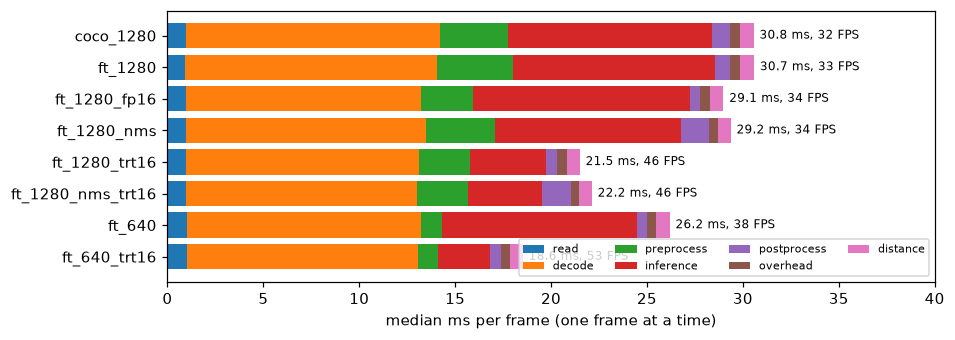

In [3]:
stages = ("read", "decode", "preprocess", "inference", "postprocess", "overhead", "distance")
show = ["coco_1280", "ft_1280", "ft_1280_fp16", "ft_1280_nms", "ft_1280_trt16", "ft_1280_nms_trt16", "ft_640", "ft_640_trt16"]
vals = np.array([[LAT[c][s]["median_ms"][0] for s in stages] for c in show])
left = np.zeros(len(show))
for j, s in enumerate(stages):
    plt.barh(show, vals[:, j], left=left, label=s)
    left += vals[:, j]
for i, c in enumerate(show):
    plt.text(left[i] + 0.3, i, f"{LAT[c]['total']['median_ms'][0]:.1f} ms, {np.mean(LAT[c]['fps_per_round']):.0f} FPS", va="center", fontsize=8)
plt.gca().invert_yaxis(); plt.xlabel("median ms per frame (one frame at a time)"); plt.xlim(0, 40)
plt.legend(ncol=4, fontsize=7, loc="lower right"); plt.show()

Đọc biểu đồ:
- **Giải nén** (decode) tốn 12–13 ms ở mọi cấu hình, nhiều hơn cả chạy mạng bằng PyTorch
  (khoảng 10,5 ms).
- **TensorRT** cắt phần mạng từ 10,5 xuống khoảng 4 ms.
- Giảm đầu vào từ 1280 xuống 640 **gần như không** làm PyTorch nhanh hơn (10,1 so với 10,5 ms),
  dù số điểm ảnh giảm hơn ba lần. Mục 5 giải thích vì sao.
- NMS (postprocess 1,5 so với khoảng 0,6 ms) tốn khoảng 1 ms.

## 4. Luật Amdahl

**Phát biểu.** Nếu một phần $p$ của thời gian được tăng tốc $s$ lần, còn phần $1-p$ giữ nguyên,
thì cả hệ nhanh lên

$$S = \frac{1}{(1 - p) + p/s}, \qquad S \le \frac{1}{1-p} \text{ dù } s \to \infty.$$

**Ký hiệu mới**
- $p$: tỉ lệ thời gian của phần được tối ưu · $s$: hệ số tăng tốc của phần đó · $S$: tăng tốc cả hệ

Áp vào dự án: chặng inference chiếm $p$ bao nhiêu của tổng, và TensorRT đáng giá bao nhiêu?

In [4]:
base, trt = LAT["ft_1280"], LAT["ft_1280_trt16"]
p = base["inference"]["median_ms"][0] / base["total"]["median_ms"][0]
s = base["inference"]["median_ms"][0] / trt["inference"]["median_ms"][0]
S = 1 / ((1 - p) + p / s)
print(f"inference is p = {p:.0%} of the serial total; TensorRT makes it s = {s:.1f}x faster")
print(f"Amdahl: whole pipeline {S:.2f}x faster (ceiling {1 / (1 - p):.2f}x even with infinitely fast inference)")
print(f"measured: {base['total']['median_ms'][0]:.1f} -> {trt['total']['median_ms'][0]:.1f} ms = "
      f"{base['total']['median_ms'][0] / trt['total']['median_ms'][0]:.2f}x")

inference is p = 34% of the serial total; TensorRT makes it s = 2.7x faster
Amdahl: whole pipeline 1.27x faster (ceiling 1.52x even with infinitely fast inference)
measured: 30.7 -> 21.5 ms = 1.43x


Mạng chỉ chiếm khoảng một phần ba thời gian, nên dù TensorRT nhanh gấp 2,6–2,7 lần, Amdahl chỉ
hứa 1,27 lần cho cả hệ, và **không tối ưu mạng nào** đưa được hệ thống quá 1,52 lần chừng nào các
chặng khác giữ nguyên. Đo được 1,43 lần, cao hơn dự báo, vì hai chặng khác cũng đổi: preprocess
nhanh hơn 1,2 ms (TensorRT nhận đầu vào fp16), và giải nén trong lần đo đó nhanh hơn khoảng 1 ms
(dao động của CPU giữa các cấu hình, cùng một phiên). Cộng lại: $30{,}7 - 6{,}5 - 1{,}2 - 1{,}0 \approx 22$ ms, khớp 21,5 ms. Đây cũng là bài học của vlm-speedrun: trước khi
tối ưu, đo xem thời gian thật sự đi đâu.

## 5. Giới hạn khởi chạy kernel

**Hai định dạng số.** Mặc định PyTorch tính bằng **fp32**: số thực 32 bit (1 bit dấu, 8 bit mũ,
23 bit phần định trị), khoảng 7 chữ số thập phân có nghĩa. **fp16** dùng 16 bit (1 dấu, 5 mũ, 10
định trị): khoảng 3 chữ số có nghĩa, giá trị lớn nhất 65.504. Nó tốn nửa bộ nhớ, và trên GPU có
**lõi tensor** (tensor cores: khối phần cứng chuyên nhân ma trận nhỏ) thì phép nhân ma trận fp16
nhanh hơn fp32 nhiều lần. Với suy luận (không huấn luyện), độ chính xác 3 chữ số là đủ: dự án đo
được cùng mAP ở fp32 và fp16. T4 không hỗ trợ bf16, định dạng 16 bit có phạm vi rộng như fp32.

**Tính trần lý thuyết.** YOLO26n cần 5,5 GFLOPs ở đầu vào $640\times640$ (số của nhà phát triển).
Ở $1280\times416$ số điểm ảnh gấp $\tfrac{1280\cdot416}{640\cdot640} = 1{,}3$ lần, tức khoảng 7,2 GFLOPs.
T4 đạt tối đa khoảng 8 TFLOPS ở fp32 và 65 TFLOPS ở fp16 (lõi tensor).

**Ký hiệu mới**
- **FLOP**: một phép cộng hoặc nhân số thực · GFLOPs $= 10^9$ FLOP · TFLOPS $= 10^{12}$ FLOP mỗi giây
- **kernel**: một chương trình nhỏ chạy trên GPU; phần lớn phép toán của PyTorch khởi chạy một kernel (các phép chỉ đổi cách nhìn dữ liệu, như `view`, thì không)

In [5]:
gflop = 5.5 * (1280 * 416) / (640 * 640)
for name, tflops in (("fp32", 8.1), ("fp16 tensor cores", 65)):
    print(f"{gflop:.1f} GFLOP at {tflops} TFLOPS ({name}): {gflop / tflops:.2f} ms if the GPU were fully busy")
print(f"measured PyTorch inference: {LAT['ft_1280']['inference']['median_ms'][0]:.1f} ms (fp32), "
      f"{LAT['ft_1280_fp16']['inference']['median_ms'][0]:.1f} ms (fp16)")

7.2 GFLOP at 8.1 TFLOPS (fp32): 0.88 ms if the GPU were fully busy
7.2 GFLOP at 65 TFLOPS (fp16 tensor cores): 0.11 ms if the GPU were fully busy
measured PyTorch inference: 10.5 ms (fp32), 11.3 ms (fp16)


Mạng chạy chậm hơn trần lý thuyết **hơn mười lần**. GPU không bận tính toán; nó chủ yếu **chờ**.
Chờ gì? Ở chế độ eager, PyTorch chạy từng phép toán một: Python gọi xuống C++, C++ chuẩn bị tham
số, khởi chạy một kernel lên GPU. Mỗi lần như vậy tốn vài micro giây trên CPU, bất kể kernel nhỏ
hay lớn. Đếm số phép toán của một lần chạy mạng (trên CPU của bạn, một ảnh):

**Ký hiệu mới**
- **eager**: chế độ chạy từng phép toán ngay khi Python gặp nó, không biên dịch trước cả đồ thị

In [6]:
import torch
from torch.profiler import profile, ProfilerActivity
from ultralytics import YOLO
torch.set_num_threads(4)
net = YOLO("../weights/yolo26n.pt").model.fuse().eval()   # fused, as Ultralytics runs it
x = torch.zeros(1, 3, 416, 1280)
with torch.no_grad():
    net(x)                                                     # warm-up
    with profile(activities=[ProfilerActivity.CPU]) as prof:
        net(x)
n_ops = sum(e.count for e in prof.key_averages() if e.key.startswith("aten::"))
t = LAT["ft_1280"]["inference"]["median_ms"][0]
print(f"{n_ops} PyTorch operations per forward pass -> {t / n_ops * 1000:.1f} microseconds each on the Kaggle T4 run")

YOLO26n summary (fused): 120 layers, 2,408,932 parameters, 0 gradients, 5.5 GFLOPs


USDT:2026-09-27 23:40:04 495117:495117 SyncActivityProfilerHandler.cpp:52] profiler_start
USDT:2026-09-27 23:40:04 495117:495117 SyncActivityProfilerHandler.cpp:59] profiler_stop


1321 PyTorch operations per forward pass -> 8.0 microseconds each on the Kaggle T4 run


Khoảng 1.300 phép toán, tức khoảng 8 micro giây cho mỗi phép. Đó đúng là cỡ chi phí gọi và khởi
chạy một kernel từ Python trên CPU Xeon 2,0 GHz của Kaggle. Mạng bị giới hạn bởi **số lần khởi
chạy**, không phải bởi số phép tính. Đây là suy luận từ ba dấu hiệu khớp nhau (trần lý thuyết,
chi phí mỗi phép, và hai quan sát ngay dưới đây); dự án chưa đo trực tiếp bằng profiler trên GPU.
Từ đó:
- **fp16 không giúp** (11,3 so với 10,5 ms): nó làm mỗi kernel tính nhanh hơn, nhưng kernel vốn đã
  xong trước khi kernel sau kịp được gửi tới.
- **Giảm đầu vào xuống 640 gần như không giúp** với PyTorch: số kernel vẫn vậy.
- **TensorRT giúp nhiều**: Ultralytics xuất mạng sang **ONNX** (một định dạng mô tả đồ thị tính
  toán, độc lập với PyTorch), rồi TensorRT, thư viện suy luận của NVIDIA, biên dịch cả đồ thị đó
  trước, **gộp** nhiều phép toán liền nhau (tích
  chập, chuẩn hoá, hàm kích hoạt) thành một kernel, chọn sẵn kernel nhanh nhất cho T4, rồi chạy cả
  đồ thị từ C++ mà không quay lại Python. Số lần khởi chạy giảm mạnh, và khi đó độ phân giải bắt
  đầu có ý nghĩa: 640 chạy 2,7 ms so với 3,9 ms ở 1280.

## 6. Giải nén PNG

KITTI lưu ảnh dạng **PNG**: nén không mất thông tin, file lớn (khoảng 800 KB mỗi khung), giải nén
chậm. Camera thật thường gửi luồng video hoặc JPEG (nén có mất mát, file nhỏ, giải nén nhanh hơn).
Đo ngay trên CPU của bạn với các khung của chuỗi 0012:

In [7]:
paths = [kitti.image_path(ROOT, "0012", i) for i in range(40)]
png = [np.frombuffer(open(p, "rb").read(), np.uint8) for p in paths]
jpg = [cv2.imencode(".jpg", cv2.imdecode(b, cv2.IMREAD_COLOR), [cv2.IMWRITE_JPEG_QUALITY, 95])[1] for b in png]
cv2.setNumThreads(1)
def per_frame_ms(blobs, rounds=3):
    t = time.perf_counter()
    for _ in range(rounds):
        for b in blobs:
            cv2.imdecode(b, cv2.IMREAD_COLOR)
    return (time.perf_counter() - t) / (rounds * len(blobs)) * 1e3
print(f"PNG : {np.mean([len(b) for b in png]) / 1e3:6.0f} KB, decode {per_frame_ms(png):5.2f} ms per frame (this CPU, 1 thread)")
print(f"JPEG: {np.mean([len(b) for b in jpg]) / 1e3:6.0f} KB, decode {per_frame_ms(jpg):5.2f} ms per frame (quality 95)")
print(f"Kaggle run, PNG decode: {LAT['ft_1280']['decode']['median_ms'][0]:.1f} ms")

PNG :    803 KB, decode  8.93 ms per frame (this CPU, 1 thread)


JPEG:    189 KB, decode  2.07 ms per frame (quality 95)
Kaggle run, PNG decode: 13.1 ms


Máy bạn nhanh hơn CPU của Kaggle, nhưng tỉ lệ vẫn giữ: JPEG giải nén nhanh hơn PNG vài lần. Trong
một hệ thống thật, chặng này phụ thuộc vào định dạng camera gửi tới, không phải vào mô hình.

## 7. Pipeline

Khi CPU giải nén khung $k+1$ trong lúc GPU chạy mạng cho khung $k$, hai chặng **gối nhau**. Thông
lượng khi đó bị chặn bởi chặng chậm hơn:

$$\text{FPS}_{\text{pipeline}} \approx \frac{1}{\max(t_{\text{CPU}},\; t_{\text{GPU}})}, \qquad
\text{FPS}_{\text{nối tiếp}} = \frac{1}{t_{\text{CPU}} + t_{\text{GPU}}}.$$

Mô phỏng trên máy bạn: một luồng phụ giải nén PNG thật; luồng chính "chạy mạng" bằng
`time.sleep` 4 ms (như TensorRT; `sleep` nhả khoá GIL của Python giống như lúc chờ GPU).

**Ký hiệu mới**
- **GIL** (global interpreter lock): khoá khiến chỉ một luồng Python chạy mã Python tại một thời
  điểm; OpenCV và việc chờ GPU nhả khoá này, nên hai luồng thật sự chạy song song

In [8]:
def decode(b):
    return cv2.imdecode(b, cv2.IMREAD_COLOR)

def serial(blobs, gpu_ms):
    t = time.perf_counter()
    for b in blobs:
        decode(b); time.sleep(gpu_ms / 1e3)
    return len(blobs) / (time.perf_counter() - t)

def pipelined(blobs, gpu_ms):
    t = time.perf_counter()
    with ThreadPoolExecutor(1) as pool:
        nxt = pool.submit(decode, blobs[0])
        for i in range(len(blobs)):
            nxt.result()
            if i + 1 < len(blobs):
                nxt = pool.submit(decode, blobs[i + 1])
            time.sleep(gpu_ms / 1e3)
    return len(blobs) / (time.perf_counter() - t)

d = per_frame_ms(png, 1)
for gpu_ms in (4.0, 10.0):
    print(f"GPU {gpu_ms:4.1f} ms, decode {d:.1f} ms: serial {serial(png, gpu_ms):5.1f} FPS (theory {1e3 / (d + gpu_ms):5.1f}) | "
          f"pipelined {pipelined(png, gpu_ms):5.1f} FPS (theory {1e3 / max(d, gpu_ms):5.1f})")
print("Kaggle, fine-tuned + NMS, TensorRT: serial %.0f FPS, pipelined %.0f FPS" %
      (np.mean(LAT["ft_1280_nms_trt16"]["fps_per_round"]), np.mean(LAT["ft_1280_nms_trt16_pipelined"]["fps_per_round"])))

GPU  4.0 ms, decode 8.5 ms: serial  67.6 FPS (theory  80.3) | pipelined  96.7 FPS (theory 118.3)


GPU 10.0 ms, decode 8.5 ms: serial  43.0 FPS (theory  54.2) | pipelined  86.6 FPS (theory 100.0)
Kaggle, fine-tuned + NMS, TensorRT: serial 46 FPS, pipelined 71 FPS


Mô phỏng gần công thức: thấp hơn lý thuyết vài phần trăm đến khoảng 15%, là chi phí của
`sleep` và của việc chuyển qua lại giữa hai luồng. Trên Kaggle, TensorRT cộng pipeline đạt khoảng 71 khung/giây. Giới hạn
kế tiếp là chính luồng giải nén: $1/12{,}5\text{ ms} = 80$ khung/giây. Muốn nhanh hơn nữa phải giải
nén song song nhiều khung (nhiều luồng) hoặc đổi định dạng đầu vào, không phải tối ưu thêm mạng.

## Tóm tắt

- Độ trễ là thời gian cho một khung; thông lượng là số khung mỗi giây; pipeline tăng thông lượng, không giảm độ trễ.
- Đo GPU phải đồng bộ trước khi đọc đồng hồ; dự án dùng bộ bấm giờ có đồng bộ của Ultralytics.
- Luật Amdahl: mạng chỉ chiếm một phần ba thời gian nên tối ưu mạng có trần khoảng 1,5 lần.
- YOLO26n trong PyTorch bị giới hạn bởi khoảng 1.300 lần khởi chạy kernel (cỡ 8 µs mỗi lần), không
  bởi tính toán; vì vậy fp16 và giảm độ phân giải gần như vô ích, còn TensorRT (gộp kernel, chạy từ C++) nhanh gấp 2,6 lần.
- Giải nén PNG là chặng chậm nhất; pipeline che nó đi, đạt 71 khung/giây, trần kế tiếp khoảng 80.